In [2]:
from simple_markov_chain_lib import markov_chain

# ΠΑΡΑΔΟΤΕΟ 1

## Ερώτημα 1

Όταν η αλυσίδα επιστρέφει στην κατάσταση 1, ο χρόνος επιστροφής T_1 είναι ένας χρόνος διακοπής. Έτσι, λόγω  της Ισχυρής Μαρκοβιανής Ιδιότητας, η αλυσίδα "ξεχνάει" όλο το παρελθόν της τη στιγμή που φτάνει στο 1. Το μέλλον της από εκείνη τη στιγμή και μετά εξαρτάται μόνο από το γεγονός ότι βρίσκεται στο 1, ακριβώς όπως και τη χρονική στιγμή 0. Στη συγκεκριμένη μας άσκηση, αυτό σημαίνει ότι κάθε εκδρομή  αποτελεί ένα ανεξάρτητο στατιστικό πείραμα από τις προηγούμενες εκδρομές. Άρα, αν ορίσουμε την τυχαία μεταβλητή Υ^(j)_k να είναι το πλήθος των επισκέψεων στην κατάσταση j κατά την k-οστή εκδρομή, οι Y^(j)_1,...,Y^(j)_N είναι iid και από τον νόμο των μεγάλων αριθμών παίρνουμε ορθώς το αποτέλεσμα του αναμενόμενου αριθμού επισκέψεων σε κάθε κατάσταση κατά τη διάρκεια μιας εκδρομής γύρω από την κατάσταση  1 .

## Ερώτημα 2

In [3]:
## Build Markov Chain
markov_table = {
    1: {2: 0.5, 3: 0.5},
    2: {1: 1/3, 4: 2/3},
    3: {3: 0.8, 4: 0.2},
    4: {1: 0.6, 4: 0.4}
}

init_dist = {1: 1.0} # the chain starts from state 1

mc = markov_chain(markov_table, init_dist)

N = 100_000

## Initialize the dictionary "visits"
visits = {state: 0 for state in (1, 2, 3, 4)}

mc.start()
completed = 0

## Simulate N excursions
while completed < N:
    visits[mc.running_state] += 1
    mc.move()
    if mc.running_state == 1:
        completed +=1

print("Εκτίμηση  π_1:")
for x, y in visits.items():
    print("%d: %.5f" % (x, y / mc.steps))

Εκτίμηση  π_1:
1: 0.18538
2: 0.09255
3: 0.46435
4: 0.25771


Τρέχοντας τον κώδικα 2-3 φορές, παρατηρούμε ότι οι τιμές που τυπώνονται παραμένουν πολύ σταθερές (που σημαίνει μικρή διασπορά) λόγω του μεγάλου αριθμού εκδρομών (N=100.000). Συγκρίνοντας τα αριθμητικά αποτελέσματα της προσομοίωσης με τον θεωρητικό υπολογισμό, βλέπουμε ότι ταυτίζονται απόλυτα, επιβεβαιώνοντας εμπειρικά το Θεώρημα 21.

## Ερώτημα 3

Οι αλλαγές στον κώδικα:

Για να υπολογίσουμε προσεγγιστικά την κατανομή π_2(και αντίστοιχα για τις υπόλοιπες π_3 & π_4), οι μόνες γραμμές που πρέπει να αλλάξουν στον αρχικό κώδικα είναι η αρχικοποίηση της κατανομής και η συνθήκη ελέγχου για την ολοκλήρωση της εκδρομής:

### Αλλαγή 1: Η αλυσίδα ξεκινάει πλέον από την κατάσταση 2
`init_dist = {2: 1.0}`

#### Αλλαγή 2: Η εκδρομή ολοκληρώνεται όταν η αλυσίδα επιστρέψει στο 2
    if mc.running_state == 2:
        completed += 1

Τρέχοντας τον κώδικα για τις διαφορετικές καταστάσεις αναφοράς (i=2,3,4), παρατηρούμε ότι τα αριθμητικά αποτελέσματα που τυπώνονται είναι πρακτικά τα ίδια (ταυτίζονται με την π_1 και με τη θεωρητική αναλλοίωτη κατανομή π.)

Αυτό το αποτέλεσμα επιβεβαιώνει τη θεωρία των Μαρκοβιανών Αλυσίδων. Η συγκεκριμένη αλυσίδα είναι πεπερασμένη και μη υποβιβάσιμη, καθώς από κάθε κατάσταση μπορούμε να μεταβούμε σε οποιαδήποτε άλλη.

Όπως ξέρουμε από την θεωρία, μια πεπερασμένη και μη υποβιβάσιμη Μαρκοβιανή αλυσίδα έχει μοναδική αναλλοίωτη κατανομή π. Έτσι,δεν έχει καμία σημασία ποια κατάσταση θα επιλέξουμε ως σημείο αναφοράς για να μετρήσουμε τις εκδρομές και να υπολογίσουμε την κατανομή π σύμφωνα με το Θεώρημα 21. Άρα, ισχύει π_1=π_2=π_3=π_4 = π.

# ΠΑΡΑΔΟΤΕΟ 2

## Ερώτημα 1

In [4]:
from numpy import random, pi

Ntrials, Nhits = 1_000_000, 0

for n in range(Ntrials):
    x, y, z = random.uniform(-1, 1, 3)

    if x**2 + y**2 + z**2 < 1:
        Nhits += 1

est_V3 = 8 * (Nhits / Ntrials)
th_V3 = (4 * pi) / 3
relative_error = 100 * abs(1 - est_V3 / th_V3)

print("Monte Carlo estimator of: %.5f" % est_V3)
print("Actual value of V(3): %.5f" % th_V3)
print("The relative error is: %.5f%%" % relative_error)

Monte Carlo estimator of: 4.18626
Actual value of V(3): 4.18879
The relative error is: 0.06031%


## Ερώτημα 2

### Σχόλιο:
Πρέπει να βρούμε  το τετράγωνο S  που περικλείει σίγουρα τον λημνίσκο.
Μετατρέποντας την ανισότητα σε πολικές συντεταγμένες (x=rcosθ,y=rsinθ):

(r^2)^2 ≤2∣rcosθ⋅rsinθ∣ ⟹ r^4 ≤ 2r^2 * ∣sinθcosθ∣ ⟹ r^2 ≤ ∣sin(2θ)∣

Επειδή το μέγιστο της συνάρτησης ∣sin(2θ)∣ είναι 1, η μέγιστη ακτίνα του σχήματος είναι r=1. Άρα, ολόκληρος ο λημνίσκος χωράει  μέσα στο τετράγωνο με πλευρές από −1 έως 1. Επομένως, θα συνεχίσουμε να παίρνουμε δείγματα με `random.uniform(-1, 1, 2)`.

Total number of samples drawn 20032
Number of samples in the Lemniscate 10000


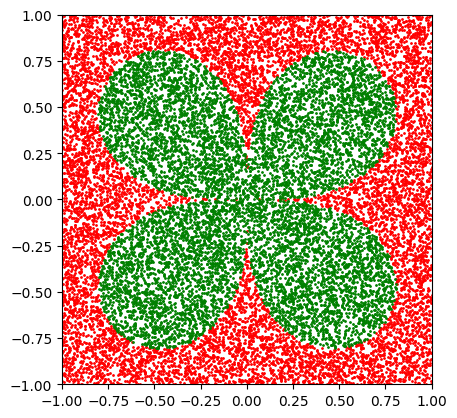

In [15]:
import matplotlib.pyplot as plt
from numpy import random

N = 10_000
Ntrials, Nhits = 0, 0
acc_x, acc_y = [], []
rej_x, rej_y = [], []

while Nhits < N:
    Ntrials += 1
    x, y = random.uniform(-1, 1, 2)

    if (x**2 + y**2)**2 <= 2 * abs(x * y):
        acc_x.append(x)
        acc_y.append(y)
        Nhits += 1
    else:
        rej_x.append(x)
        rej_y.append(y)

print("Total number of samples drawn %d" % Ntrials)
print("Number of samples in the Lemniscate %d" % N)

fig, ax = plt.subplots()

ax.scatter(rej_x, rej_y, color='red', s=1)
ax.scatter(acc_x, acc_y, color='green', s=1)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_aspect('equal')

plt.show()

## Ερώτημα 3

In [22]:
from numpy import random

Ntrials = 1_000_000
Nhits = 0
partial = 0.0

for n in range(Ntrials):
    x, y = random.uniform(-1, 1, 2)

    if (x**2 + y**2)**2 <= 2 * abs(x * y):
        Nhits += 1
        partial += abs(x + y)

S = 4.0
L = S * (Nhits / Ntrials)

# E[|X1 + X2|]
exp_value = partial / Nhits

I = L * exp_value

print("Monte Carlo with %d samples:" % Ntrials)
print("Estimated |L|: %.5f" % L)
print("E[|X_1 + X_2|]: %.5f" % exp_value)
print("Estimated integral I: %.5f" % I)

Monte Carlo with 1000000 samples:
Estimated |L|: 1.99934
E[|X_1 + X_2|]: 0.49481
Estimated integral I: 0.98929
